### Function imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import uxarray as ux
import intake
import healpix as hp
import holoviews as hv

import easygems.healpix as egh
import easygems.remap as egr

import easygems.healpix as eghp

import cmocean
import geoviews.feature as gf


sigma = 5.67E-8  # Stefan-Boltzmann constant (W/m^2/K^4)

### (Optional) Using Dask to parallize tasks

In [29]:
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client
from dask.distributed import performance_report

rda_scratch = '/glade/derecho/scratch/khirata/'

cluster = PBSCluster(
    job_name = 'dask-wk24-hpc',
    cores = 8,
    memory = '64GiB',
    processes = 8,
    local_directory = rda_scratch+'/dask/spill',
    log_directory = rda_scratch + '/dask/logs/',
    resource_spec = 'select=1:ncpus=1:mem=8GB',
    queue = 'casper',
    walltime = '12:00:00',
    #interface = 'ib0'
    interface = 'ext'
)

cluster.scale(5)

### Define the catalog

In [6]:
zoom_lev = 8

In [2]:
node_id = 'NCAR'
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[node_id]

In [4]:
import pandas as pd

pd.DataFrame(cat["ew_dyamond3_2D"].describe()["user_parameters"])

,name,description,type,allowed,default
0,time,temporal resolution of the dataset,str,"[PT1H, PT3H]",PT1H
1,zoom,zoom resolution of the dataset,int,"[9, 8, 7, 6, 5, 4, 3, 2, 1]",7


In [13]:
ds_ew = cat['ew_dyamond3_2D'](zoom=8,time='PT1H').to_dask()

/glade/u/apps/opt/conda/envs/2025-digital-earths-global-hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [14]:
ds_ew

<xarray.Dataset> Size: 193GB
Dimensions:      (time: 8760, cell: 786432, nbnd: 2)
Coordinates:
  * time         (time) datetime64[ns] 70kB 2020-03-01T01:00:00 ... 2021-03-01
Dimensions without coordinates: cell, nbnd
Data variables: (12/14)
    crs          (time) int64 70kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    date         (time) int32 35kB dask.array<chunksize=(24,), meta=np.ndarray>
    datesec      (time) int32 35kB dask.array<chunksize=(24,), meta=np.ndarray>
    pr           (time, cell) float32 28GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    psl          (time, cell) float32 28GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    rlut         (time, cell) float32 28GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    ...           ...
    ts           (time, cell) float32 28GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    uas          (time, cell) float32 28GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    vas          (time, cell) float32 28GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    orog         (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    sftgif       (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    sftlf        (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>

### Define the zoom level

In [16]:
time_slice = slice("2019-01-01", "2021-03-01")

### Plots for testing and debugging

In [33]:
# test_toggle = True
test_toggle = False

diurnal = False

### Read in data into UxArray (precipitation)

In [21]:
scl_icon = 86400. #kg/m2/s to mm/day
ds_icon = cat['icon_d3hp003'](zoom=zoom_lev).to_dask()
uxds_icon = ux.UxDataset.from_healpix(ds_icon)
uxda_pr_icon = uxds_icon['pr'].sel(time=time_slice) #*scl_icon # mm/day

scl_scream = 86400.*1000. #m/s to mm/day
ds_scream = cat['scream2D_hrly'](zoom=zoom_lev).to_dask()
uxds_scream = ux.UxDataset.from_healpix(ds_scream)
uxda_pr_scream = uxds_scream['pr'].sel(time=time_slice) #*scl_scream # mm/day

scl_nicam = 86400. #kg/m2/s to mm/day
ds_nicam = cat['nicam_gl11'](zoom=zoom_lev, time='PT3H').to_dask()
uxds_nicam = ux.UxDataset.from_healpix(ds_nicam)
uxds_nicam.assign_coords(hour=uxds_nicam.time.dt.hour)
uxds_nicam.assign_coords(month=uxds_nicam.time.dt.month)
uxda_pr_nicam = uxds_nicam['pr'].sel(time=time_slice) #*scl_nicam # mm/day

scl_mpas = 48. #mm/30min to mm/day
ds_mpas = cat['mpas_dyamond3'](zoom=zoom_lev, time='PT30M').to_dask()
uxds_mpas = ux.UxDataset.from_healpix(ds_mpas)
uxda_pr_mpas = uxds_mpas['rainnc'].sel(time=time_slice) #*scl_nicam # mm/day


# scl_imerg = 24. #mm/hr to mm/day
# uxds_imerg = ux.UxDataset.from_healpix('/glade/derecho/scratch/andrew/hackathon/IMERG_V07B_hp9.zarr')
# scl_imerg = 24. #mm/hr to mm/day
# ds_imerg = cat['IR_IMERG'](zoom=9).to_dask()
# uxds_imerg = ux.UxDataset.from_healpix(ds_imerg)

# uxda_pr_imerg_fine = uxds_imerg['precipitation'].sel(time=time_slice)
# uxda_pr_imerg_fine = uxda_pr_imerg_fine.chunk({'time': 48, 'n_face': uxda_pr_imerg_fine.sizes['n_face']})

# level_down = 9 - zoom_lev
# uxda_pr_imerg_tmp = uxda_pr_imerg_fine
# for i in range(level_down):
#     uxda_pr_imerg_tmp = uxda_pr_imerg_tmp.coarsen(n_face=4).mean()
#     uxda_pr_imerg_tmp['crs'].attrs['healpix_nside'] = 2**int(9 - i - 1)
# uxda_pr_imerg = uxda_pr_imerg_tmp

# # level_down = 9 - zoom_lev
# # for i in range(level_down):
# #     uxds_imerg = uxds_imerg.coarsen(n_face=4).mean()
# #     uxds_imerg['crs'].attrs['healpix_nside'] = 2**int(9 - i - 1) #hp_nside // 2
# # uxda_rlut_imerg_rename = uxds_imerg.rename({'n_face': 'cell'})
# # uxds_imerg = ux.UxDataset.from_healpix(uxda_rlut_imerg_rename)

# # uxda_pr_imerg_orig = uxds_imerg['precipitation'].sel(time=time_slice)
# # uxda_pr_imerg_orig = uxda_pr_imerg_orig.chunk({'time': 48, 'n_face': uxda_pr_imerg_orig.sizes['n_face']})
# uxda_pr_imerg = uxda_pr_imerg.resample(time='1H').first().compute() #*scl_imerg # mm/day


/glade/u/apps/opt/conda/envs/2025-digital-earths-global-hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/glade/u/apps/opt/conda/envs/2025-digital-earths-global-hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/glade/u/apps/opt/conda/envs/2025-digital-earths-global-hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of

In [17]:
scl_ew = 86400. #kg/m2/s to mm/day
ds_ew = cat['ew_dyamond3_2D'](zoom=zoom_lev,time='PT1H').to_dask()
uxds_ew = ux.UxDataset.from_healpix(ds_ew)
uxds_ew.assign_coords(hour=uxds_ew.time.dt.hour)
uxds_ew.assign_coords(month=uxds_ew.time.dt.month)
uxda_pr_ew = uxds_ew['pr'].sel(time=time_slice) #*scl_ew # mm/day

scl_mpas = 48. #mm/30min to mm/day
ds_mpas = cat['mpas_dyamond3'](zoom=zoom_lev, time='PT30M').to_dask()
uxds_mpas = ux.UxDataset.from_healpix(ds_mpas)
uxda_pr_mpas = uxds_mpas['rainnc'].sel(time=time_slice) #*scl_nicam # mm/day


# scl_imerg = 24. #mm/hr to mm/day
# uxds_imerg = ux.UxDataset.from_healpix('/glade/derecho/scratch/andrew/hackathon/IMERG_V07B_hp9.zarr')
# scl_imerg = 24. #mm/hr to mm/day
# ds_imerg = cat['IR_IMERG'](zoom=9).to_dask()
# uxds_imerg = ux.UxDataset.from_healpix(ds_imerg)


/glade/u/apps/opt/conda/envs/2025-digital-earths-global-hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [18]:
### Make all months for UM
threshold = 1
frequency_ew_all = (uxda_pr_ew > threshold / scl_ew).groupby("time.month").mean("time").compute()

In [19]:
frequency_ew_all.sel(month=2).plot()

:Image   [x,y]   (x_y pr)

In [20]:
frequency_ew_all.to_netcdf("frequency_gt_1mm_ew.nc")

In [ ]:
month = 2 # February !!

threshold = 1 # mm/day

frequency_scream = (uxda_pr_scream > threshold / scl_scream).groupby("time.month").mean("time").sel(month=month).compute()
frequency_icon = (uxda_pr_icon > threshold / scl_icon).groupby("time.month").mean("time").sel(month=month).compute()
frequency_nicam = (uxda_pr_nicam > threshold / scl_nicam).groupby("time.month").mean("time").sel(month=month).compute()
# frequency_imerg = (uxda_pr_imerg > threshold / scl_imerg).groupby("time.month").mean("time").sel(month=month).compute()

In [ ]:
uxda_pr_mpas_diff = uxda_pr_mpas.diff(dim="time", label="lower")
frequency_mpas = (uxda_pr_mpas_diff * scl_mpas > threshold).groupby("time.month").mean("time").sel(month=month).compute()

1081
1080


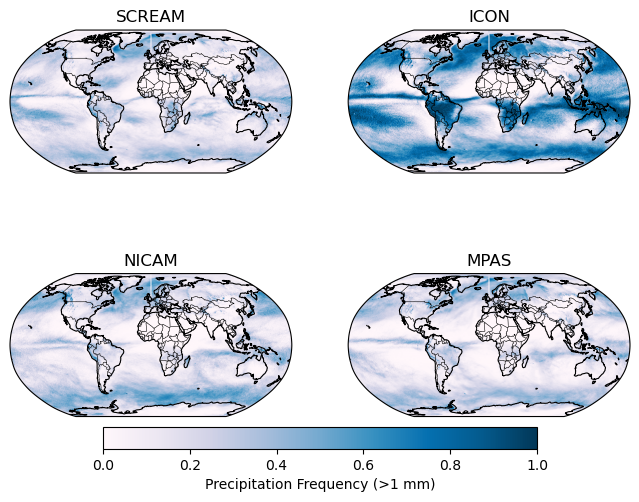

In [ ]:
%matplotlib inline

# month = 6

# pr_freq_scream = (uxda_pr_scream > threshold).groupby("time.month").mean("time")
# pr_freq_icon   = (uxda_pr_icon > threshold).groupby("time.month").mean("time")
# pr_freq_nicam  = (uxda_pr_nicam > threshold).groupby("time.month").mean("time")
# pr_freq_imerg  = (uxda_pr_imerg > threshold).groupby("time.month").mean("time")

fig, axes = plt.subplots(2, 2, figsize=(8, 6), subplot_kw={'projection': ccrs.Robinson()})

axes[0, 0].set_global()
axes[0, 0].set_title("SCREAM")
mappable = eghp.healpix_show(frequency_scream, ax=axes[0, 0], cmap="PuBu", vmin=0, vmax=1)
axes[0, 0].add_feature(cf.COASTLINE, linewidth=0.8)
axes[0, 0].add_feature(cf.BORDERS, linewidth=0.4)

axes[0, 1].set_global()
axes[0, 1].set_title("ICON")
mappable = eghp.healpix_show(frequency_icon, ax=axes[0, 1], cmap="PuBu", vmin=0, vmax=1)
axes[0, 1].add_feature(cf.COASTLINE, linewidth=0.8)
axes[0, 1].add_feature(cf.BORDERS, linewidth=0.4)

axes[1, 0].set_global()
axes[1, 0].set_title("NICAM")
mappable = eghp.healpix_show(frequency_nicam, ax=axes[1, 0], cmap="PuBu", vmin=0, vmax=1)
axes[1, 0].add_feature(cf.COASTLINE, linewidth=0.8)
axes[1, 0].add_feature(cf.BORDERS, linewidth=0.4)

axes[1, 1].set_global()
axes[1, 1].set_title("MPAS")
mappable = eghp.healpix_show(frequency_mpas, ax=axes[1, 1], cmap="PuBu", vmin=0, vmax=1)
axes[1, 1].add_feature(cf.COASTLINE, linewidth=0.8)
axes[1, 1].add_feature(cf.BORDERS, linewidth=0.4)

fig.colorbar(
    mappable, ax=axes[1, :], orientation='horizontal', shrink=0.7, pad=0.05,
    label="Precipitation Frequency (>1 mm)"
)

fig.suptitle(f"Precipitation Frequency ({month}) [with inconsistent time interval]", fontsize=16)

# axes[1, 1].set_global()
# axes[1, 1].set_title("IMERG")
# mappable_imerg = eghp.healpix_show(frequency_imerg, ax=axes[1, 1], cmap="BuPu", vmin=0, vmax=1)
# axes[1, 1].add_feature(cf.COASTLINE, linewidth=0.8)
# axes[1, 1].add_feature(cf.BORDERS, linewidth=0.4)

# fig.colorbar(
#     mappable_imerg, ax=axes[1, 1], orientation='horizontal', shrink=0.7, pad=0.05,
    # label="Precipitation Frequency Difference"
# )
# plt.tight_layout()

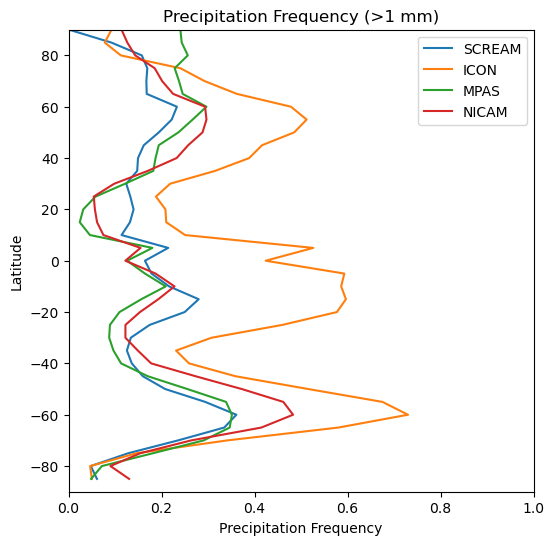

In [ ]:
month = 2

frequency_zm_scream   = frequency_scream.zonal_mean(lat=(-85, 86, 5))
frequency_zm_icon   = frequency_icon.zonal_mean(lat=(-85, 86, 5))
frequency_zm_nicam  = frequency_nicam.zonal_mean(lat=(-85, 86, 5))
frequency_zm_mpas   = frequency_mpas.zonal_mean(lat=(-85, 86, 5))

plt.figure(figsize=(6, 6))

plt.plot(frequency_zm_scream, frequency_zm_scream.latitudes, label="SCREAM")
plt.plot(frequency_zm_icon, frequency_zm_icon.latitudes, label="ICON")
plt.plot(frequency_zm_mpas, frequency_zm_mpas.latitudes, label="MPAS")
plt.plot(frequency_zm_nicam, frequency_zm_nicam.latitudes, label="NICAM")
# plt.plot(rlut_zm_imerg, rlut_zm_imerg.latitudes, label="IMERG")

plt.xlim(0, 1)
plt.ylim(-90, 90)

plt.xlabel("Precipitation Frequency")
plt.ylabel("Latitude")
plt.title("Precipitation Frequency (>1 mm)")
plt.legend()


In [ ]:
cluster.close()